In [1]:
# Windows asyncio fix - MUST BE FIRST CELL
import sys
if sys.platform == 'win32':
    try:
        import nest_asyncio
        nest_asyncio.apply()
        print('✓ Windows asyncio fix applied')
    except ImportError:
        print('⚠ nest_asyncio not installed. Run: pip install nest-asyncio')


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [3]:
import sys
if sys.platform == 'win32':
    import asyncio
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
import gc
gc.collect()

10

In [4]:
# Load JSON results from both models
from path_utils import get_output_path

results_dir = get_output_path('3_xg_boost')

with open(results_dir / "results_old.json", "r") as f:
    old = json.load(f)

with open(results_dir / "results_new.json", "r") as f:
    new = json.load(f)

print("Old model results:", list(old.keys()))
print("New model results:", list(new.keys()))

Old model results: ['raw', 'five', 'quarter', 'hourly', 'daily']
New model results: ['five', 'quarter', 'hourly', 'daily']


In [5]:
# Convert to DataFrame for easier analysis
df_old = pd.DataFrame(old).T
df_new = pd.DataFrame(new).T

# Remove raw data since mesonet only starts from five minute aggregation
keep = ["five", "quarter", "hourly", "daily"]

df_old = df_old.loc[keep]
df_new = df_new.loc[keep]

print("\nNYISO-only model metrics:")
print(df_old)
print("\nNYISO + Mesonet model metrics:")
print(df_new)



NYISO-only model metrics:
             MAPE        MAE       RMSE        R2    Time_s
five     0.371711   5.747551   7.756254  0.999237  3.414615
quarter  0.507495   8.131376  11.728080  0.998254  1.718954
hourly   2.553333  39.864424  50.354452  0.967711  1.303692
daily    4.486447  70.998032  96.334179  0.813671  0.794348

NYISO + Mesonet model metrics:
             MAPE        MAE       RMSE        R2    Time_s
five     0.260819   4.069395   5.796668  0.999574  4.859870
quarter  0.325351   5.096249   7.175701  0.999346  2.190618
hourly   1.615409  24.634511  32.334552  0.986670  0.990801
daily    3.090742  47.948223  64.179095  0.917300  0.242707


In [6]:
# Calculate improvement percentages
improvement = pd.DataFrame(index=keep)

for metric in ["MAPE", "MAE", "RMSE"]:
    # For these metrics, lower is better
    improvement[f"{metric}_improvement_%"] = ((df_old[metric] - df_new[metric]) / df_old[metric] * 100)

# For R², higher is better
improvement["R2_improvement_%"] = ((df_new["R2"] - df_old["R2"]) / df_old["R2"] * 100)

print("\nImprovement from adding Mesonet weather data:")
print(improvement.round(2))



Improvement from adding Mesonet weather data:
         MAPE_improvement_%  MAE_improvement_%  RMSE_improvement_%  \
five                  29.83              29.20               25.26   
quarter               35.89              37.33               38.82   
hourly                36.73              38.20               35.79   
daily                 31.11              32.47               33.38   

         R2_improvement_%  
five                 0.03  
quarter              0.11  
hourly               1.96  
daily               12.74  


## Comparison Plots
Visualize performance metrics across different time aggregations

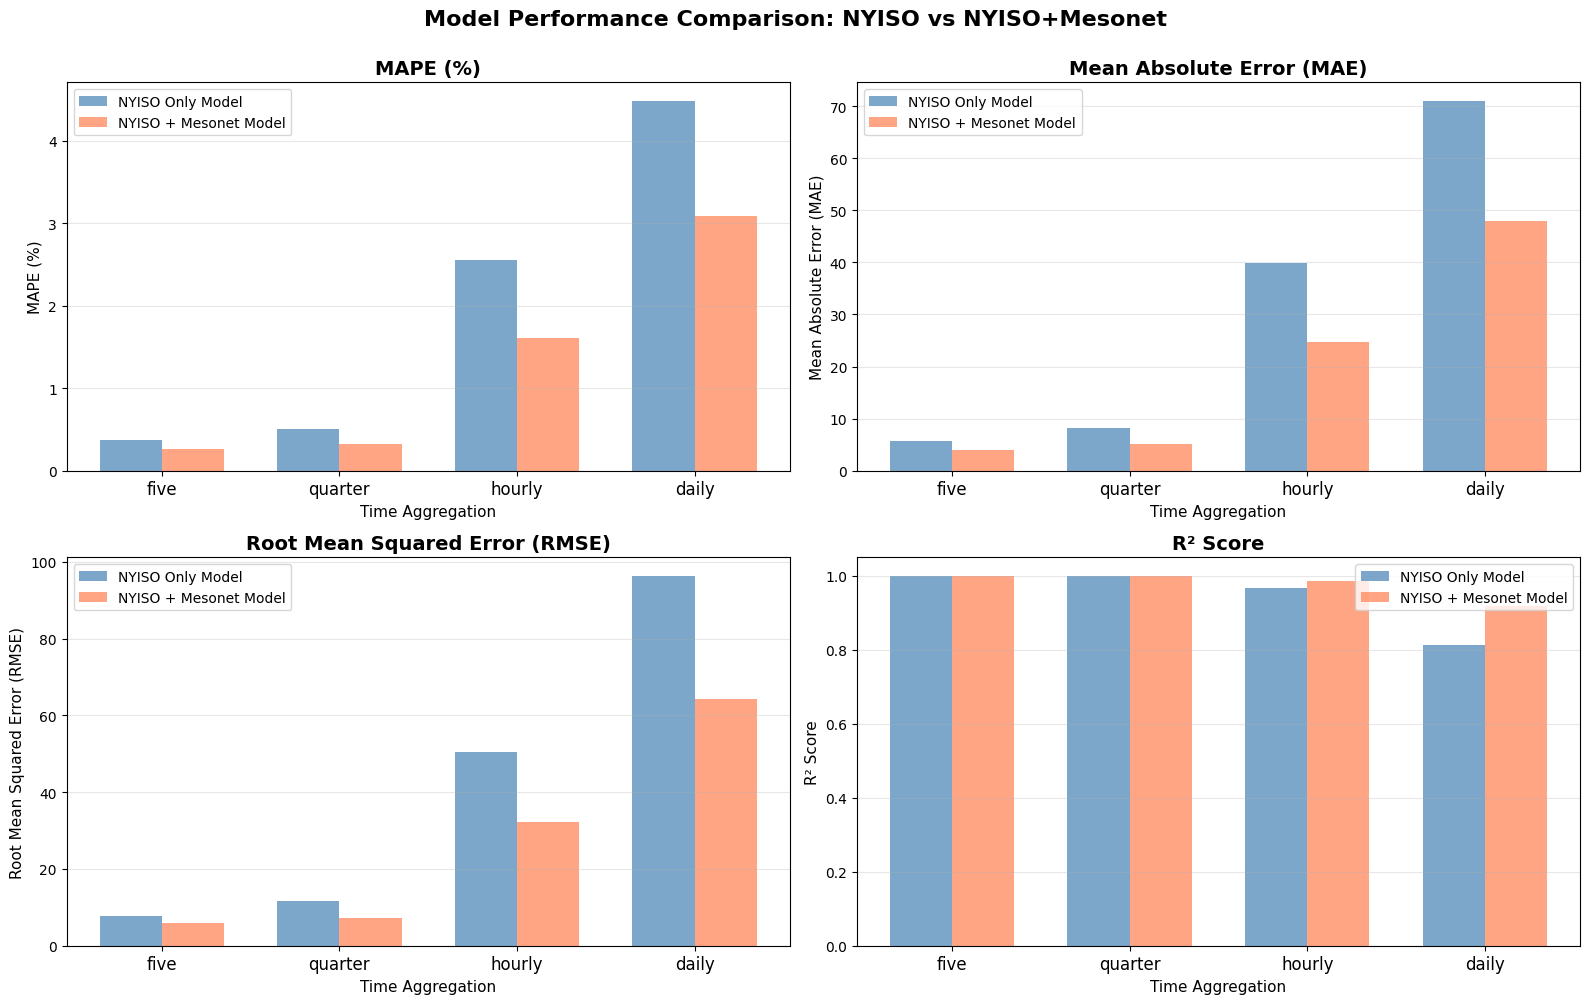

In [7]:
metrics = ["MAPE", "MAE", "RMSE", "R2"]
titles = {
    "MAPE": "MAPE (%)",
    "MAE":  "Mean Absolute Error (MAE)",
    "RMSE": "Root Mean Squared Error (RMSE)",
    "R2":   "R² Score"
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

x = np.arange(len(keep))  # positions
bar_width = 0.35

for i, metric in enumerate(metrics):
    ax = axes[i]

    old_vals = df_old[metric].values
    new_vals = df_new[metric].values

    bars1 = ax.bar(x - bar_width/2, old_vals, width=bar_width, 
                   label="NYISO Only Model", alpha=0.7, color='steelblue')
    bars2 = ax.bar(x + bar_width/2, new_vals, width=bar_width, 
                   label="NYISO + Mesonet Model", alpha=0.7, color='coral')

    ax.set_title(titles[metric], fontsize=14, weight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(keep, fontsize=12)
    ax.set_xlabel("Time Aggregation", fontsize=11)
    ax.set_ylabel(titles[metric], fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    # Improve spacing for tight metrics
    if metric == "R2":
        ax.set_ylim(0, 1.05)

    ax.legend(loc='best')

plt.suptitle("Model Performance Comparison: NYISO vs NYISO+Mesonet", 
             fontsize=16, weight='bold', y=1.00)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


## Summary Statistics

In [8]:
# Calculate average improvement across all aggregations
avg_improvement = improvement.mean()
print("Average improvement across all time aggregations:")
print(avg_improvement.round(2))

# Find best performing aggregation for each model
print("\n" + "="*60)
print("Best performing time aggregation:")
print("="*60)
for metric in ["MAPE", "MAE", "RMSE"]:
    old_best = df_old[metric].idxmin()
    new_best = df_new[metric].idxmin()
    print(f"{metric}:")
    print(f"  NYISO-only: {old_best} ({df_old.loc[old_best, metric]:.4f})")
    print(f"  + Mesonet:  {new_best} ({df_new.loc[new_best, metric]:.4f})")

# R² - higher is better
old_best = df_old["R2"].idxmax()
new_best = df_new["R2"].idxmax()
print(f"R²:")
print(f"  NYISO-only: {old_best} ({df_old.loc[old_best, 'R2']:.4f})")
print(f"  + Mesonet:  {new_best} ({df_new.loc[new_best, 'R2']:.4f})")


Average improvement across all time aggregations:
MAPE_improvement_%    33.39
MAE_improvement_%     34.30
RMSE_improvement_%    33.31
R2_improvement_%       3.71
dtype: float64

Best performing time aggregation:
MAPE:
  NYISO-only: five (0.3717)
  + Mesonet:  five (0.2608)
MAE:
  NYISO-only: five (5.7476)
  + Mesonet:  five (4.0694)
RMSE:
  NYISO-only: five (7.7563)
  + Mesonet:  five (5.7967)
R²:
  NYISO-only: five (0.9992)
  + Mesonet:  five (0.9996)


In [9]:
# Create detailed comparison table
comparison_table = pd.DataFrame()
for metric in metrics:
    comparison_table[f"{metric}_old"] = df_old[metric]
    comparison_table[f"{metric}_new"] = df_new[metric]
    if metric in ["MAPE", "MAE", "RMSE"]:
        comparison_table[f"{metric}_Δ%"] = improvement[f"{metric}_improvement_%"]
    else:
        comparison_table[f"{metric}_Δ%"] = improvement[f"{metric}_improvement_%"]

print("\nDetailed Comparison Table:")
print(comparison_table.round(4))

# Save to CSV
comparison_table.to_csv("model_comparison_detailed.csv")
print("\nSaved detailed comparison to: model_comparison_detailed.csv")



Detailed Comparison Table:
         MAPE_old  MAPE_new  MAPE_Δ%  MAE_old  MAE_new   MAE_Δ%  RMSE_old  \
five       0.3717    0.2608  29.8330   5.7476   4.0694  29.1978    7.7563   
quarter    0.5075    0.3254  35.8909   8.1314   5.0962  37.3261   11.7281   
hourly     2.5533    1.6154  36.7333  39.8644  24.6345  38.2043   50.3545   
daily      4.4864    3.0907  31.1094  70.9980  47.9482  32.4654   96.3342   

         RMSE_new  RMSE_Δ%  R2_old  R2_new    R2_Δ%  
five       5.7967  25.2646  0.9992  0.9996   0.0337  
quarter    7.1757  38.8161  0.9983  0.9993   0.1094  
hourly    32.3346  35.7861  0.9677  0.9867   1.9591  
daily     64.1791  33.3787  0.8137  0.9173  12.7360  

Saved detailed comparison to: model_comparison_detailed.csv
